# Smart Banking: Predicting Customer Term Deposit Subscriptions Using Machine Learning

In [1]:
import pandas as pd
import numpy as np

# import dataset
df = pd.read_csv('bank.csv')

# first few rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Data Wrangling and Scaling

In [2]:
# check number of rows and columns
df.shape
# data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [3]:
# summary statistics for numerical columns
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


# Sampling Methods

In [4]:
# 1. Random Sampling - 20% sample of entire dataset
random_sample = df.sample(frac=0.2, random_state=42)

# 2. Systematic Sampling - every 5th record starting from 0
systematic_sample = df.iloc[::5, :]

print("Random sample size:", random_sample.shape)
print("Systematic sample size:", systematic_sample.shape)

Random sample size: (2232, 17)
Systematic sample size: (2233, 17)


# Descriptive Statistics 

In [5]:
# Descriptive statistics for numeric variables
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
# Descriptive statistics for categorical variables
df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


# Visualizations

### 1. Scatter Plot

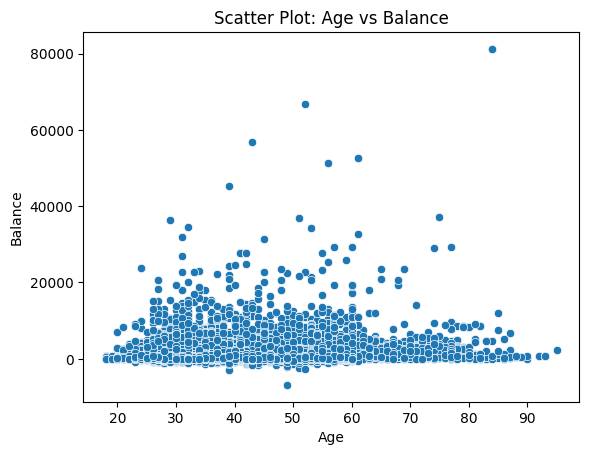

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Age vs Balance
sns.scatterplot(x='age', y='balance', data=df)
plt.title('Scatter Plot: Age vs Balance')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.show()


### 2. Box plot

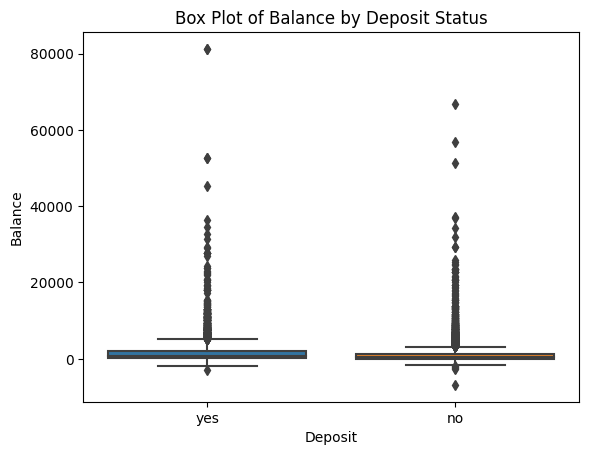

In [8]:
# Box plot: Balance by Deposit Status
sns.boxplot(x='deposit', y='balance', data=df)
plt.title('Box Plot of Balance by Deposit Status')
plt.xlabel('Deposit')
plt.ylabel('Balance')
plt.show()

### 3. Histogram

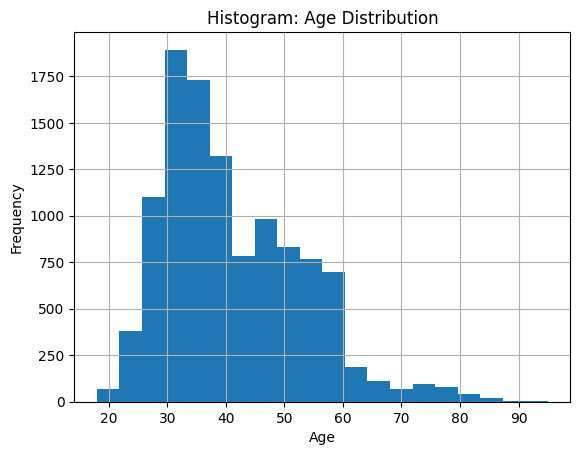

In [9]:
# Histogram: Age Distribution
df['age'].hist(bins=20)
plt.title('Histogram: Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### 4. Heat map

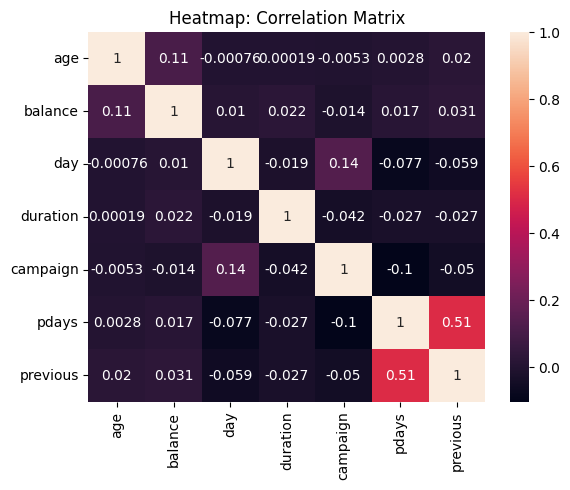

In [10]:
# Heatmap: Correlation Matrix
numeric_df = df[['age','balance','day','duration','campaign','pdays','previous']]
sns.heatmap(numeric_df.corr(), annot=True)
plt.title('Heatmap: Correlation Matrix')
plt.show()

## Pearson Correlation Test

In [13]:
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder
# Encode deposit variable
le = LabelEncoder()
df['deposit_encoded'] = le.fit_transform(df['deposit'])

corr, p_val = pearsonr(df['duration'], df['deposit_encoded'])
print(f"Pearson r: {corr:.3f}, p-value: {p_val:.4f}")


Pearson r: 0.452, p-value: 0.0000


## Chi-Square (Categorical)

In [14]:
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['job'], df['deposit_encoded'])
chi2, p, dof, ex = chi2_contingency(contingency)
print(f"Chi-square p-value: {p:.4f}")


Chi-square p-value: 0.0000


## One Sample T-test

In [15]:
from scipy.stats import ttest_1samp

# Use original age column (before scaling)
population_mean = df['age'].mean()

# Make sure sampling also uses the original data
sample_df = df.sample(n=150, random_state=42)

# Perform t-test
t_stat, p_val = ttest_1samp(sample_df['age'], population_mean)

print("Population Mean (Age):", round(population_mean, 2))
print("Sample Mean (Age):", round(sample_df['age'].mean(), 2))
print(f"t-statistic: {t_stat:.2f}, p-value: {p_val:.4f}")


Population Mean (Age): 41.23
Sample Mean (Age): 40.13
t-statistic: -1.02, p-value: 0.3087


# Regression Models: Simple and Multiple

### Scale the numerical columns for modelling

In [16]:
from sklearn.preprocessing import StandardScaler

# numeric columns to scale
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the numeric columns and transform them in-place
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# summary statistics to confirm mean ~ 0 and std ~ 1
print(df[numeric_cols].describe().T[['mean', 'std']])


                  mean       std
age       2.749995e-16  1.000045
balance   1.018517e-17  1.000045
day      -2.037033e-17  1.000045
duration  8.148134e-17  1.000045
campaign  3.055550e-17  1.000045
pdays     5.092584e-18  1.000045
previous -2.037033e-17  1.000045


### Simple Regression

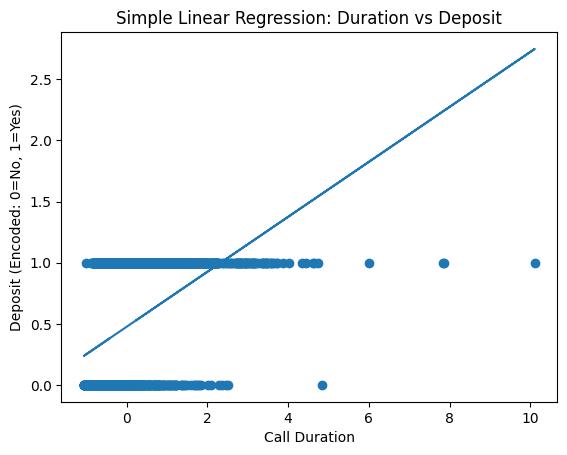

0.21467784166535098

In [17]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score



# Simple Regression Model
X = df[['duration']]
y = df['deposit_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

# Plot regression line
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_simple)
plt.title("Simple Linear Regression: Duration vs Deposit")
plt.xlabel("Call Duration")
plt.ylabel("Deposit (Encoded: 0=No, 1=Yes)")
plt.show()

# Show Rsqd score
r2_score(y_test, y_pred_simple)


### Multiple Regression

In [18]:

# Features and target
X = df[['age', 'balance', 'duration', 'campaign']]
y = df['deposit_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create and fit the multiple linear regression model
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

# Prediction
y_pred_multiple = model_multiple.predict(X_test)

# coefficients and intercept
print(f"Intercept: {model_multiple.intercept_}")
print("Coefficients:")
for feature, coef in zip(X.columns, model_multiple.coef_):
    print(f"  {feature}: {coef}")

# Calculate R-squared
r2 = r2_score(y_test, y_pred_multiple)

# Create a DataFrame for pretty table output
results_df = pd.DataFrame({
    'Metric': ['R-squared'],
    'Value': [round(r2, 3)]
})
results_df

Intercept: 0.47570033334771605
Coefficients:
  age: 0.012287889053684473
  balance: 0.0383704626773685
  duration: 0.2215179972166396
  campaign: -0.05282773837478237


,Metric,Value
0,R-squared,0.229


# Classification Models: Logistic Regression, KNN, Naïve Bayes, Decision Tree

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df

,Model,Accuracy
0,Logistic Regression,0.725481
1,KNN,0.726377
2,Naive Bayes,0.712942
3,Decision Tree,0.665025


## Confusion Matrix

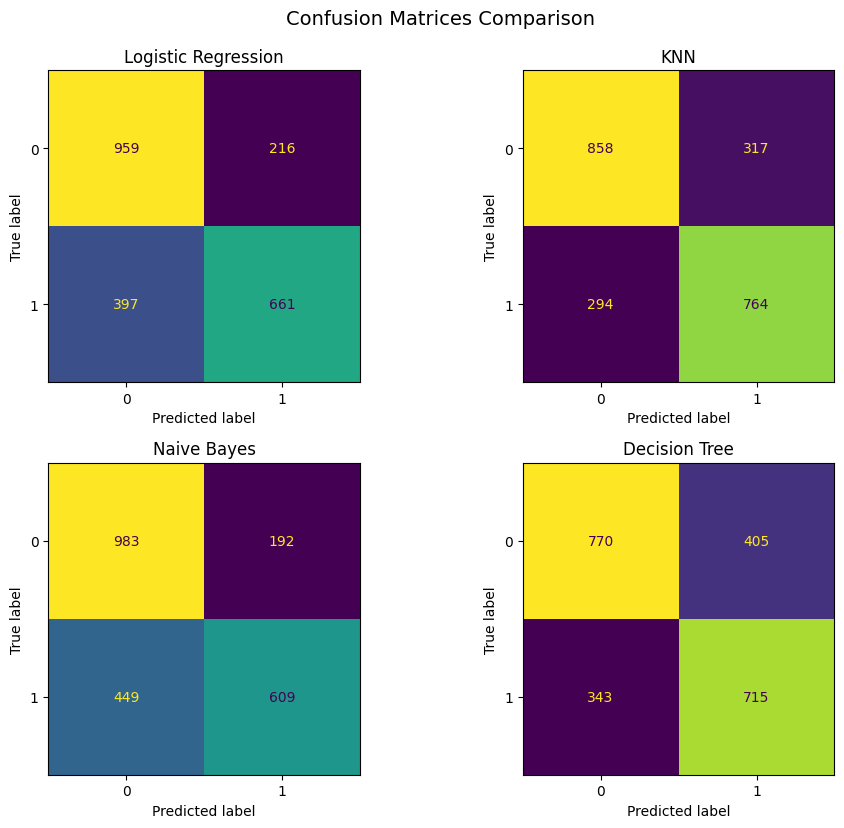

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.suptitle("Confusion Matrices Comparison", fontsize=14, y=1.03)
plt.show()


## Best-Fit Classifier Selection

In [20]:
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print("\nBest Model Based on Accuracy:")
best_model



Best Model Based on Accuracy:


Model            KNN
Accuracy    0.726377
Name: 1, dtype: object

# Clustering Analysis

## K-Means

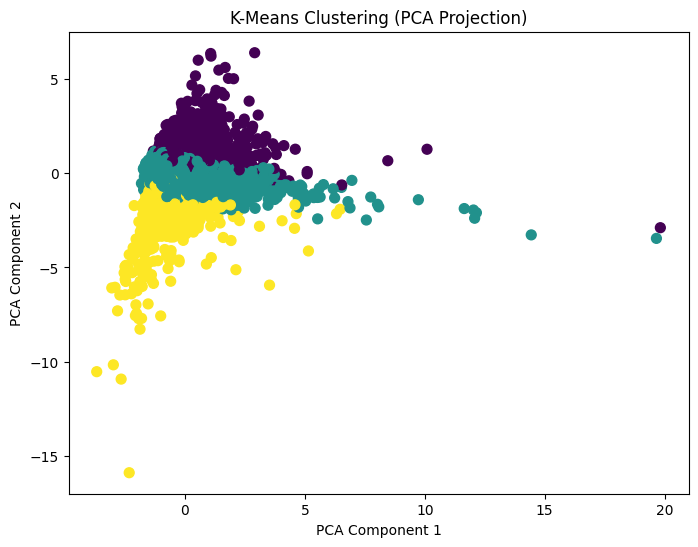

In [21]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Features to cluster
X = df[['age', 'balance', 'duration', 'campaign']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize and fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Reduce to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['kmeans_cluster'], cmap='viridis', s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering (PCA Projection)')
plt.show()


## Hierarchical

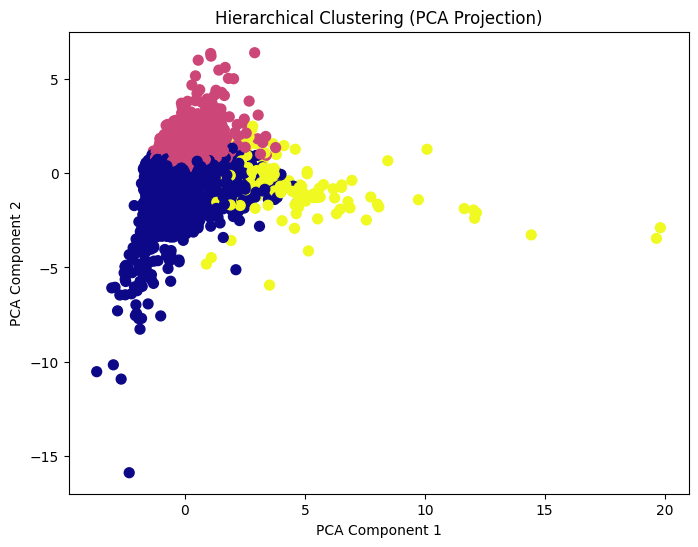

In [22]:
from sklearn.cluster import AgglomerativeClustering

X = df[['age', 'balance', 'duration', 'campaign']]

X_scaled = StandardScaler().fit_transform(X)

hierarchical = AgglomerativeClustering(n_clusters=3)
df['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['hierarchical_cluster'], cmap='plasma', s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Hierarchical Clustering (PCA Projection)')
plt.show()
